# Создание и оптимизация ResNet18

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import json

Загрузка логов обучения.

In [64]:
from enum import IntEnum

# user-defined index.
class usid(IntEnum):
    mdl_4x2_ReLU_Adam = 0
    mdl_3x2_ReLU_Adam = 1
    mdl_4x3_ReLU_Adam = 2
    mdl_4x1_ReLU_Adam = 3
    mdl_4x2_LeakyReLU_Adam = 4
    mdl_4x2_ELU_Adam = 5
    mdl_4x2_GELU_Adam = 6
    mdl_4x2_ReLU_AdamW = 7

# Имена моделей.
model_names = [e.name for e in usid]

In [65]:
DATA_NUM = len(usid)

log_dir = Path("./train_logs/")
log_data = np.empty(DATA_NUM, dtype='object')
log_data_df = np.empty(DATA_NUM, dtype='object')
model_struct = np.empty(DATA_NUM, dtype='object')
for idx, name in enumerate(model_names):
    with open(log_dir / (name + ".json"), "r") as f:
        log_data[idx] = json.load(f)
        log_data_df[idx] = pd.DataFrame(log_data[idx].get("train_log"))
        model_struct[idx] = log_data[idx].get("model_architecture")

Настройки форматирования графиков.

In [66]:
user_figsize = (10, 6)
user_fontsize = 16
# legend_fontsize: 'xx-small', 'x-small', 'small', 'medium', 'large', 'x-large', 'xx-large'
line_type = ['-', ':']*len(model_names)
plot_mark = ['', 'o']

tab10_colors = [
    '#1f77b4',  # tab:blue
    '#ff7f0e',  # tab:orange
    '#2ca02c',  # tab:green
    '#d62728',  # tab:red
    '#9467bd',  # tab:purple
    '#8c564b',  # tab:brown
    '#e377c2',  # tab:pink
    '#7f7f7f',  # tab:gray
    '#bcbd22',  # tab:olive
    '#17becf']  # tab:cyan

plot_titles = ["Losses", "Accuracy"]
plot_legend = ['train', 'validation']
plot_xlabel = "epoch"
plot_ylabels = ["loss", "accuracy"]
METRIC_NUM = len(plot_titles)

## Часть 2: Базовая архитектура ResNet18

### 2.5: Визуализация базовых результатов

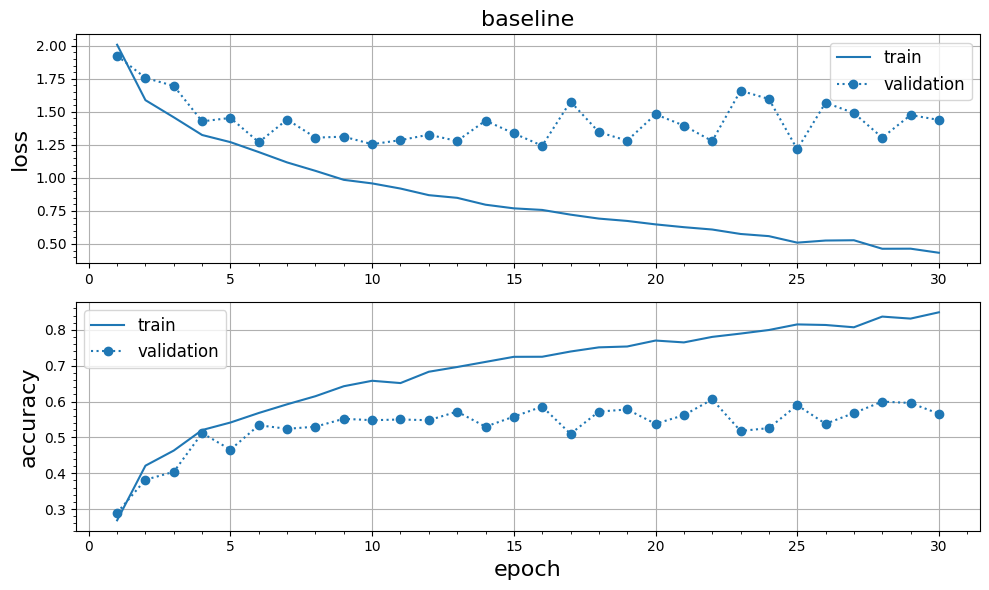

In [67]:
plot_idx = [usid.mdl_4x2_ReLU_Adam.value]
fig, axs = plt.subplots(ncols=1, nrows=2, figsize=user_figsize)
for k, ax in enumerate(axs):
    if k == 0:
        ax.set_title("baseline", fontsize=user_fontsize)
    else:
        ax.set_xlabel(plot_xlabel, fontsize=user_fontsize)
    for idx in plot_idx:
        for m in range(METRIC_NUM):
            ax.plot(
                log_data_df[idx].iloc[:,0], 
                log_data_df[idx].iloc[:,2*m+k+1],
                marker=plot_mark[m],
                linestyle=line_type[m],
                color=tab10_colors[idx]
                )
    ax.set_ylabel(plot_ylabels[k], fontsize=user_fontsize)
    ax.legend(plot_legend, fontsize='large')
    ax.grid()
    ax.minorticks_on()
    
plt.tight_layout()
plt.savefig('readme_img/loss_acc_4x2_ReLU_Adam.png', bbox_inches='tight')
plt.show()

## Часть 3: Поэтапная оптимизация модели

### 3.1: Оптимизация количества каналов

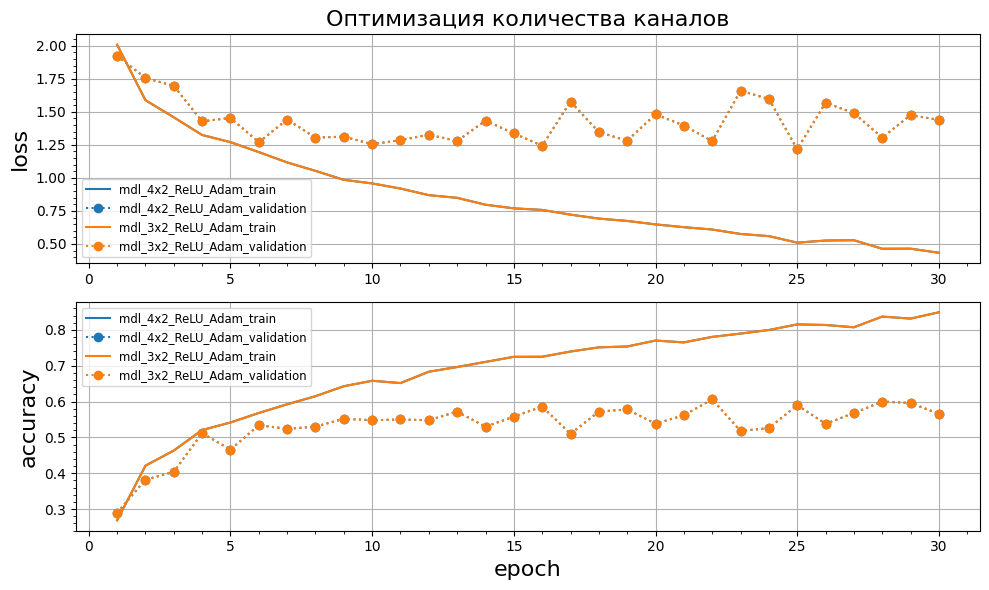

In [68]:
plot_idx = [usid.mdl_4x2_ReLU_Adam.value, usid.mdl_3x2_ReLU_Adam.value]
plot_legend_local = []
fig, axs = plt.subplots(ncols=1, nrows=2, figsize=user_figsize)
for k, ax in enumerate(axs):
    if k == 0:
        ax.set_title("Оптимизация количества каналов", fontsize=user_fontsize)
    else:
        ax.set_xlabel(plot_xlabel, fontsize=user_fontsize)
    for idx in plot_idx:
        for m in range(METRIC_NUM):
            ax.plot(
                log_data_df[idx].iloc[:,0], 
                log_data_df[idx].iloc[:,2*m+k+1],
                marker=plot_mark[m],
                linestyle=line_type[m],
                color=tab10_colors[idx]
                )
        plot_legend_local.extend([model_names[idx] + '_' + tp for tp in plot_legend])
    ax.set_ylabel(plot_ylabels[k], fontsize=user_fontsize)
    ax.legend(plot_legend_local, fontsize='small')
    ax.grid()
    ax.minorticks_on()
    
plt.tight_layout()
plt.savefig('readme_img/loss_acc_4x2_vs_3x2_ReLU_Adam.png', bbox_inches='tight')
plt.show()

### 3.2: Эксперименты с количеством residual блоков

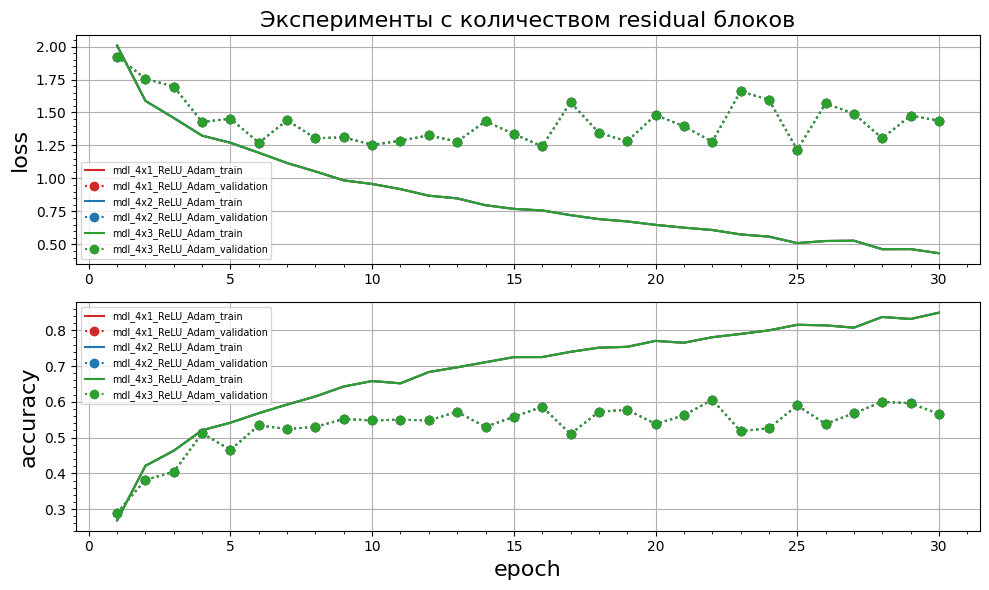

In [69]:
plot_idx = [usid.mdl_4x1_ReLU_Adam.value, usid.mdl_4x2_ReLU_Adam.value, usid.mdl_4x3_ReLU_Adam.value]
plot_legend_local = []
fig, axs = plt.subplots(ncols=1, nrows=2, figsize=user_figsize)
for k, ax in enumerate(axs):
    if k == 0:
        ax.set_title("Эксперименты с количеством residual блоков", fontsize=user_fontsize)
    else:
        ax.set_xlabel(plot_xlabel, fontsize=user_fontsize)
    for idx in plot_idx:
        for m in range(METRIC_NUM):
            ax.plot(
                log_data_df[idx].iloc[:,0], 
                log_data_df[idx].iloc[:,2*m+k+1],
                marker=plot_mark[m],
                linestyle=line_type[m],
                color=tab10_colors[idx]
                )
        plot_legend_local.extend([model_names[idx] + '_' + tp for tp in plot_legend])
    ax.set_ylabel(plot_ylabels[k], fontsize=user_fontsize)
    ax.legend(plot_legend_local, fontsize='x-small')
    ax.grid()
    ax.minorticks_on()
    
plt.tight_layout()
plt.savefig('readme_img/loss_acc_4x1_vs_4x2_vs_4x3_ReLU_Adam.png', bbox_inches='tight')
plt.show()